In [8]:
using Test, Plots

# Unit Testing in Julia & DIVACoast.jl

`DIVACoast.jl` is a collaborative project, where changes made by one contributor can affect the work of others. As a dynamic and multipurpose package for flood modelling, it is crucial to ensure consistency, accuracy, and reliability throughout its development. Julia’s built-in `Test.jl` package offers essential tools for unit testing, enabling automated verification of code after each modification or release. This helps to quickly detect and resolve unexpected issues, maintaining the integrity of the package. This notebook provides an overview of unit testing concepts and demonstrates how to implement them in Julia and within `DIVACoast.jl`.

## What is "Unit Testing"?

> […] Unit testing is a way to **see if your code is correct** by checking that the **results are what you expect**. It can be helpful to ensure your code still works after you make changes, and can be used when developing as a way of specifying the behaviors your code should have when complete.<br>- *Julia Documentation "Unit Testing"*

> Unit testing, a.k.a. component or module testing, is a form of software testing by which **isolated source code is tested** to validate expected behavior.<br>- *Wikipedia "Unit Testing"*

> Unit testing is the process of **testing the smallest parts of your code**, like it is a method in which we verify the code's correctness by running one by one. It's a key part of software development that **improves code quality** by testing each unit in isolation. [...] It will work as the function inputs and verifying the outputs. These tests check that the **code work as expected based on the logic the developer intended**.<br>- *geeksforgeeks.org "Unit Testing - Software Testing"*

### Takeaways
1. Unit testing involves checking individual components of code to **ensure they behave as expected**
2. Helps to verify correctness after changes and serves as **specification for desired code behavior**
3. Are Written to validate **isolated parts of the code**, making it easier to detect and fix issues early.

### Questions
1. How do we define a "Unit"?
2. How do we test a "Unit"?
3. What approaches or tools can we use to verify that a unit behaves as expected?

---

## What is a "Unit"?

> A unit is defined as a **single behaviour exhibited by the system under test** (SUT), usually corresponding to a requirement. While a unit may correspond to a single function or module or a single method or class, functions/methods and modules/classes do not necessarily correspond to units. From the system requirements perspective only the perimeter of the system is relevant, thus **only entry points to externally visible system behaviours define units**. <br>*- Wikipedia "Unit Testing"*

### Takeaways 
1. A unit is an isolated part of your code that someone from the outside can see or use. 
2. A unit is defined by what it does, not by how it is organized -> Its defined by behavior from the outside
---

## How to test?
*based on [geeksforgeeks.org](https://www.geeksforgeeks.org/software-testing/unit-testing-software-testing/) with additions and changes*

The most commonly used approach in Unit Testing is the: *test - function - expected value* approach. This means you write a test that calls a function (or unit of code) with specific input, and then check if the output matches the expected value. If the actual output equals the expected value, the test passes; otherwise, it fails. 

There is a broad range of techniques for Unit Testing, the four main techniques are:
1. **Logic Check**  
Verify the code performs correct calculations and follows the expected path with valid inputs. Check all possible paths through the code. 

2. **Boundary Checks**  
Test how the system handles typical, edge cases, and invalid inputs.

3. **Error handling**  
Check if the system properly handles errors. Does it prompt for a new input, or does it crash when something goes wrong?

4. **Object-oriented checks**  
If the code modifies (mutates) an object, confirm that the object's state is correctly updated after running the code.

also:

5. **Consistency Checks**  
Ensure that the unit produces consistent results for the same input and maintains internal consistency across related operations.

6. **Performance Testing**  
Assess whether the unit performs efficiently under expected workloads and does not introduce bottlenecks.

7. **Integration Checks**  
Verify that the unit interacts correctly with other components or modules, especially at defined interfaces.

8. **Regression Testing**  
Ensure that previously passing tests continue to pass after changes, preventing old bugs from reappearing.
---

## Unit-Testing in Julia

Julia provides a base package `Test.jl` for Unit testing. You define a test using the `@test` followed by the expression you want to test (function - expected value). Let's look at a simple test scenario, where we define a `add()` function for adding two values `a` and `b`.

In [9]:
# Example function to be tested
function add(a, b)
    return a + b
end

# We can now write tests for this functions using the @test macro
@test add(2, 3) == 5 # We expect that adding 2 and 3 gives us 5
@test add(-1, 1) == 0

# Due to the commutative law of addition, we expect that add(a, b) == add(b, a)
@test add(3, 2) == add(2, 3)

# We can also compare the behavior of our function to a known correct implementation
@test add(2.5, 3.5) == +(2.5, 3.5)
@test add(2.5, 3.5) == 2.5 + 3.5

Test Passed

From the Julia Documentation:

> Typically a large number of tests are used to make sure functions work correctly over a range of inputs. In the event a test fails, the **default behavior is to throw an exception immediately**. However, it is normally preferable to run the rest of the tests **first to get a better picture of how many errors there are** in the code being tested.<br>*- Julia Documentation "Unit Testing"*

Therefore, we can organize our tests into `@testsets` for each unit, allowing us to see a summary of all test results rather than stopping at the first failure. For example, in our case:



In [15]:
@testset "addition" begin
    # We can now write tests for this functions using the @test macro
    @test add(2, 3) == 3.0 broken = true # we expect the test fails
    @test add(-1, 1) == 0

    # Due to the commutative law of addition, we expect that add(a, b) == add(b, a)
    @test add(3, 2) == add(2, 3)

    # We can also compare the behavior of our function to a known correct implementation
    @test add(2.5, 3.5) == +(2.5, 3.5)
    @test add(2.5, 3.5) == 2.5 + 3.5
end

Test Summary: | Pass  Broken  Total  Time
addition      |    4       1      5  0.0s


Test.DefaultTestSet("addition", Any[Test Broken
  Expression: add(2, 3) == 3.0], 4, false, false, true, 1.760519996271e9, 1.760519996271e9, false, "c:\\Users\\Lars\\Work\\Global_Climate_Forum\\DIVA\\DIVACoast\\notebooks\\jl_notebook_cell_df34fa98e69747e1a8f8a730347b8e2f_X11sZmlsZQ==.jl")

---
## Guide for Unit-Testing in DIVACoast.jl
*based on [testrail.com](https://www.testrail.com/blog/how-to-write-unit-tests/) with some additions and changes*
### 1. **Identify the unit's purpose**
Before you want to test a unit within your code, take a step back and ask: "What is the unit supposed to do?" Having a clear understanding of its intendend purpose will guide the rest of your test design procecss. You can identify the purpose of a unit by:<br>
    - **Requirement analysis:** reviewing the relevant specifications and requirements related to the unit<br>
    - **Code study:** Read through the code to understand its logic, dependencies, inputs, and outputs. This step helps you uncover any potential edge cases or areas of complexity.<br>
    - **Identify test scenarios:** Determine all the **potential situaitons the unit might encounter**, including error conditions and boundary cases. You can also ask others if they encountered any issues with the unit.<br> 

### 2. **Prepare the environment**
Prepare the environment in which your tests will run. This involves installing dependencies (packages) and to create a stable, consistent, isolated setup which allows you to execute reliably across different machines and environments. Key steps involve: 
    - **Setup Environment**: E.g. for `DIVACoast.jl` make sure the required packages for your unit are part of the Project environemt (`Project.toml`)
    - **Use mocks**: Instead of large datasets you can create small mocks, "mimicking" real data.
    - **Structure tests clearly**: Follow the Arrange, Act, Assert (AAA) pattern to make each test easy to read and reason about: 
        - Arrange = Set up everything the test needs (e.g., mock data, packages, ...)
        - Act = Execute the specific function or unit being tested 
        - Assert = Verify that the output or behavior matches the expected result.
### 3. **Formulate the test**<br>
Start with a narrow focus: each unit test should **validate a single behavior** or outcome. Unit test functions should be **concise, readable, and test only a small piece of logic** at a time. To reduce redundancy in your test setup, look for patterns in repeated code. If you find yourself writing the same initialization or configuration steps across multiple tests, consider, extracting does steps into **helper methods**.

### 4. **Test edge cases**<br>
Edge cases refer to rare or unexpected input scenarios that can cause a program to behave in unintended ways. While they’re often overlooked during basic testing, edge case tests are essential for verifying how robust and resilient your code really is. Here are some strategies for designing effective edge case unit tests:
    - **Use boundary values**: Test inputs at the extreme ends of acceptable ranges (e.g., the minimum and maximum allowed values).
    - **Test empty, null, or unexpected types**: Validate how the unit handles inputs like empty strings, null, or data types that don’t conform to expectations.

## Best practices for Unit Testing

### **1. Isolate Units:**
Focus on small, **isolated units of code**. Each unit should **target a single method or function**, and it should be isolated from other parts of the system. Avoid combining multiple interactions or components in the same test. Isolated tests improve reliability, reduce dependencies, and make it easier to trace the source of failures.

### **2. Prioritize readability and maintainability:**
Write tests that are **easy to read, understand, and update**. Use clear, descriptive naming conventions and **add comments** where necessary, especially when the test logic involves edge cases or complex behavior. This makes tests more accessible.

### **3. Test For Behavior, Not Implementation:**
Unit tests should **focus on verifying a function’s observable behavior** and outputs, **rather than its internal logic** or how it’s implemented. This approach helps ensure that your tests stay stable even when the underlying code structure changes. When you test for behavior instead of implementation, your tests become less brittle and easier to maintain. Developers have more flexibility to refactor code without needing to constantly rewrite test logic.

### **4. Write Tests That Fail for The Right Reasons:**
A passing test doesn’t always mean your code is correct, especially if the test isn’t validating the right behavior. Well-written unit tests should **only fail when there’s a genuine issue with the specific functionality** being tested. If a test fails for unrelated reasons or if a faulty test still passes, it can lead to confusion and false confidence in your code. Focus each test case on a single, specific behavior. Use clear and consistent assertions with informative error messages so failures are easy to trace. This ensures your tests provide reliable, actionable feedback when something breaks.

---

## Example
Let's set up a simple example for testing. Inspired by DIVACoast, we'll examine flooding on a Hypsometric Profile. Instead of focusing on exposure, we'll analyze how far a flood event with a given water level (1.3m) propagates inland.

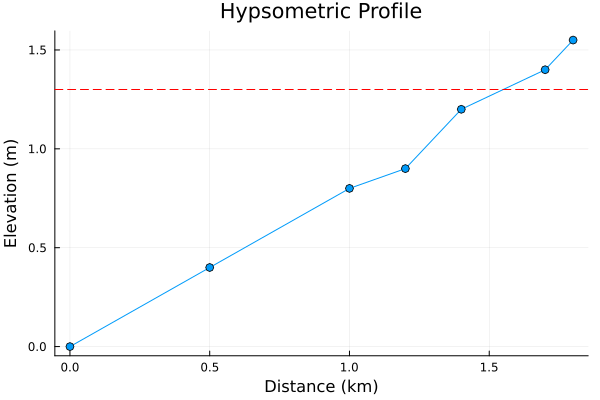

In [16]:
using Plots

# Setup our small Hypsometric Profile for testing
elevation = Float32[0.0, 0.4, 0.8, 0.9, 1.2, 1.4, 1.55]
distance = Float32[0.0, 0.5, 1.0, 1.2,  1.4, 1.7, 1.8]
water_level = 1.3

# Helper function to return a Hypsoetric Profile plot we can modfiy
hp_plot = () -> begin 
    p = plot(distance, elevation, xlabel="Distance (km)", ylabel="Elevation (m)", title="Hypsometric Profile", marker=:o, legend=false)
    hline!([water_level], color=:red, linestyle=:dash, label="Water Level")
    return p
end

hp_plot()

When looking at the Hypsometric Profile, we can see the propagation distance should be around 1.5km. 
To calculate the distance, we need to check which elevation increment will be implemented and linear interpolate within the distance interval.

Since we are not sure about the exact value, we can formulate an approximated test. Julia includes the `≈()` function, however using the test macros, you can also use the approximation operator `≈` followed by the keyword arguments for the approximate function to be consice with the `function - operator -  expected` syntax ("infix")

```julia
@test prop_distance ≈ 1.5 atol = 0.05
```
Note, that we are using the approximation parameter since we are not sure about the precise result. We define our tolerance at around 50m. 

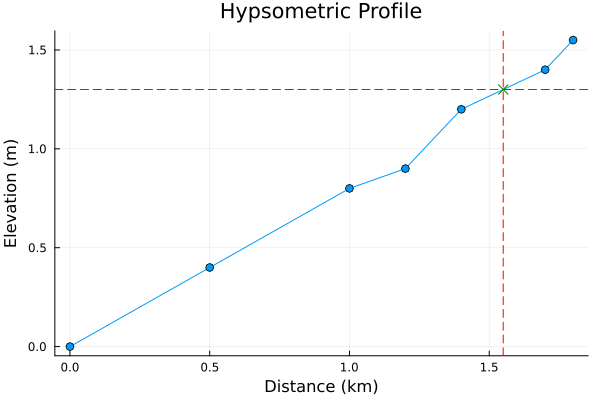

In [23]:
p = hp_plot()
prop_distance = Inf

for (i, elevation_a) in enumerate(elevation[1:end-1])
	
	elevation_b = elevation[i+1]
	
	
	if elevation_a <= water_level <= elevation_b
		# Interpolate distance between the two points
		prop_distance = distance[i] + (water_level - elevation_a) * (distance[i+1] - distance[i]) / (elevation_b - elevation_a)
		break
	end
end

vline!(p, [prop_distance], color = :red, linestyle = :dash, label = "Water Level")
plot!(p, [prop_distance], [water_level], color = :green, markersize = 5, marker = :xcross, label = "Propagation Distance")
p |> display

In [ ]:
# If you know the approximate result you can use isapprox to test it
test = @test isapprox(prop_distance, 1.5; atol = 0.05)
# Or you can also pass the keyword args to the @test macro directly
test = @test prop_distance ≈ 1.5 atol=0.05

println("Calculated Propagation Distance: ", prop_distance, " km", " | Test: ", test)

Calculated Propagation Distance: 1.549999994039525 km | Test: Test Passed


Now that we have tested our approach, it is important to identify potential pitfalls by dividing the workflow into distinct units to isolate issues. This process is also reffered to as `refactoring`.

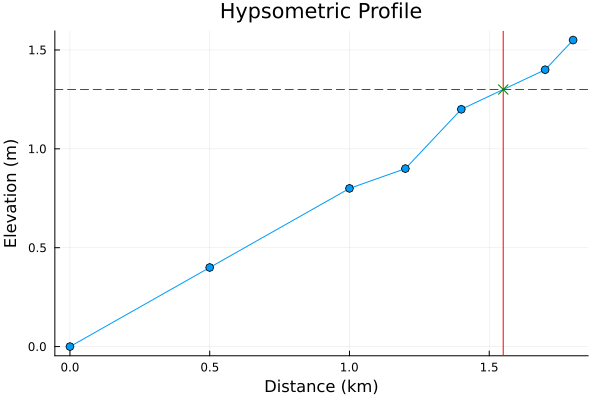

In [27]:
# We can define a function to find the elevation interval containing the target
# waterlevel and to get the corresponding distance interval
function find_interval(elevation, distance, water_level)
    for (i, elev) in enumerate(elevation[1:end-1])
        if elev <= water_level <= elevation[i + 1]
            return ((distance[i], distance[i + 1]), (elev, elevation[i + 1]))
        end
    end
    return nothing
end

# With this function we can use the intervals to interpolate the distance according to the
# waterlevel
function interpolate_distance(distance_interval, elevation_interval, water_level)
    
    elevation_a, elevation_b = elevation_interval
    distance_a, distance_b = distance_interval

    Δelevation = elevation_b - elevation_a
    Δdistance = distance_b - distance_a
    Δheight = water_level - elevation_a
    slope = Δheight / Δelevation

    propagation_distance = distance_a + (slope * Δdistance)
    return propagation_distance
end

intervals = find_interval(elevation, distance, water_level)
distance_interval, elevation_interval = intervals
prop_distance = interpolate_distance(distance_interval, elevation_interval, 1.3)

p = hp_plot()
vline!(p, [prop_distance], color=:red, linestyle=:solid, label="Propagation Distance")
plot!(p, [prop_distance], [water_level], color=:green, markersize=5, marker = :xcross, label="Propagation Distance")


We can now define a testset for our units.

In [ ]:
@testset "interpolate" begin 
    # First we can test a normal case we can calculate by hand
    @test interpolate_distance((1.0, 2.0), (1.0, 2.0), 1.0) == 1.0
    # In the second we can test a case where the elevation interval is flat
    @test interpolate_distance((0.5, 0.5), (0.0, 0.0), 0.0) == 0.5
    # In the third we can test a case where the distance interval is flat
    @test interpolate_distance((1.0, 1.0), (1.0, 2.0), 1.5) == 1.0
    # In the fourth we can test a case with reversed intervals
    @test interpolate_distance((2.0, 1.0), (2.0, 1.0), 1.5) == 1.5
    # In the fifth we can test a case where the waterlevel is outside the interval (invalid input case)
    # Therefore, we  pipe the output to the isnan function since we cannot use equality to NaN
    @test interpolate_distance((1.0, 2.0), (1.0, 2.0), 3.0) |> x -> isnan(x)
end

Test Summary: | Pass  Total  Time
interpolate   |    5      5  0.0s


Test.DefaultTestSet("interpolate", Any[], 5, false, false, true, 1.760523242798e9, 1.760523242807e9, false, "c:\\Users\\Lars\\Work\\Global_Climate_Forum\\DIVA\\DIVACoast\\notebooks\\jl_notebook_cell_df34fa98e69747e1a8f8a730347b8e2f_X23sZmlsZQ==.jl")

As we can see the test `interpolate_distance((0.5, 0.5), (0.0, 0.0), 0.0) == 0.5` failed. 
We can now target the `interpolate()` function and fix the bug. The bug is likely caused, since we do not handle the case were elevatoin becomes zero. Dividing by 0 for the elevation will return NaN. Also we don't want to return a value if the waterlevel is outside the provided interval, since we canont assume the same slope. The updated function looks like this:<br>
*\*Note: You could also throw an error if the waterlevel is outside the elevation interval using the `throw()` function*

In [66]:
function interpolate_distance(distance_interval, elevation_interval, water_level)
    elevation_a, elevation_b = elevation_interval
    distance_a, distance_b = distance_interval

    if water_level < minimum(elevation_interval) || water_level > maximum(elevation_interval)
        return NaN
    end

    Δelevation = elevation_b - elevation_a
    Δdistance = distance_b - distance_a
    Δheight = water_level - elevation_a
    # Avoid division by zero
    slope = Δelevation != 0.0 ? Δheight / Δelevation : 0.0

    propagation_distance = distance_a + (slope * Δdistance)
    return propagation_distance
end


interpolate_distance (generic function with 1 method)

We can now run our testset again. For structuring you tests even more you can define the testset within a function.

In [74]:
function interpolation_test()
    @testset "interpolate" begin 
    # First we can test a normal case we can calculate by hand
    @test interpolate_distance((1.0, 2.0), (1.0, 2.0), 1.0) == 1.0
    # In the second we can test a case where the elevation interval is flat
    @test interpolate_distance((0.5, 0.5), (0.0, 0.0), 0.0) == 0.5
    # In the third we can test a case where the distance interval is flat
    @test interpolate_distance((1.0, 1.0), (1.0, 2.0), 1.5) == 1.0
    # In the fourth we can test a case with reversed intervals
    @test interpolate_distance((2.0, 1.0), (2.0, 1.0), 1.5) == 1.5
    # In the fifth we can test a case where the waterlevel is outside the interval (invalid input case)
    # Therefore, we  pipe the output to the isnan function since we cannot use equality to NaN
    @test interpolate_distance((1.0, 2.0), (1.0, 2.0), 3.0) |> x -> isnan(x)
end
end

interpolation_test()

Test Summary: | Pass  Total  Time
interpolate   |    5      5  0.0s


Test.DefaultTestSet("interpolate", Any[], 5, false, false, true, 1.760523091688e9, 1.760523091688e9, false, "c:\\Users\\Lars\\Work\\Global_Climate_Forum\\DIVA\\DIVACoast\\notebooks\\jl_notebook_cell_df34fa98e69747e1a8f8a730347b8e2f_X36sZmlsZQ==.jl")

Now we can define a testset for the `find_interval()` function as well.

In [83]:
function find_interval_test()
    @testset "find_interval" begin
        
        # We define mock data for testing
        elevation = [0.0, 1.0, 2.0, 3.0]
        distance = [0.0, 1.0, 2.0, 3.0]

        # Normal case
        @test find_interval(elevation, distance, 1.5) == ((1.0, 2.0), (1.0, 2.0))
        # Edge case 
        @test find_interval(elevation, distance, 0.0) == ((0.0, 1.0), (0.0, 1.0))
        # Invalid input case    
        @test find_interval(elevation, distance, -1.0) |> x -> isnothing(x)
        @test find_interval(elevation, distance, 4.0) |> x -> isnothing(x)
    end
end

find_interval_test (generic function with 1 method)

And we can run all tests at once.

In [86]:
function test_inland_propagation()
    find_interval_test()
    interpolation_test()
end

test_inland_propagation()

Test Summary: | Pass  Total  Time
find_interval |    4      4  0.0s
Test Summary: | Pass  Total  Time
interpolate   |    5      5  0.0s


Test.DefaultTestSet("interpolate", Any[], 5, false, false, true, 1.760523499277e9, 1.760523499277e9, false, "c:\\Users\\Lars\\Work\\Global_Climate_Forum\\DIVA\\DIVACoast\\notebooks\\jl_notebook_cell_df34fa98e69747e1a8f8a730347b8e2f_X36sZmlsZQ==.jl")